In this notebook, we compare our previous best loss function (Proxy Anchor Loss) with a combined loss from Proxy Anchor Loss and Center loss.

## 1. Setup and Configuration

In [1]:
EXPERIMENT_NAME = "loss_combined"
RANDOM_SEED = 51

import os

os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

from pathlib import Path
import sys

PROJECT_PATH = Path.cwd().parent
sys.path.insert(0, str(PROJECT_PATH))

from dotenv import load_dotenv
import math

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
from PIL import Image
from tabulate import tabulate
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from src.utils import (
    get_device,
    set_seeds,
    create_deterministic_training_dataloader,
)
from src.visualization import visualize_embeddings_mds

set_seeds(RANDOM_SEED)

print(f"PyTorch version: {torch.__version__}")

All random seeds set to 51 for reproducibility
PyTorch version: 2.9.1+cu128


In [2]:
# Define paths
DATA_PATH = PROJECT_PATH / "data"
OUTPUT_PATH = PROJECT_PATH / "output" / EXPERIMENT_NAME
OUTPUT_PATH_SHARED = PROJECT_PATH / "output" / "shared"
CHECKPOINT_PATH = PROJECT_PATH / "checkpoints" / EXPERIMENT_NAME
EMBEDDINGS_PATH = CHECKPOINT_PATH / "embeddings"

DATA_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH_SHARED.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH.mkdir(parents=True, exist_ok=True)
EMBEDDINGS_PATH.mkdir(parents=True, exist_ok=True)

# Load environment variables from .env file
load_dotenv(dotenv_path=PROJECT_PATH / ".env")

True

In [3]:
# Configuration
config = {       
    # Dinov3 Model
    "dinov3_model": "hf-hub:timm/vit_base_patch16_dinov3.lvd1689m",
    "dinov3_input_size": 224,

    # Model
    "embedding_dim": 256,
    "hidden_dim": 512,
    "dropout": 0.3,
    
    # ProxyAnchor
    "proxyanchor_margin": 0.1,
    "proxyanchor_alpha": 32.0,
    
    # Combined Loss
    "combined_lambda": 0.5,

    # Training
    "batch_size": 32,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "num_epochs": 200,
    "patience": 10,
    "val_split": 0.2,
    
    # Reproducibility
    "seed": RANDOM_SEED,
}

print("Configuration:")
for key, value in config.items():
    print(f"  {key}: {value}")

Configuration:
  dinov3_model: hf-hub:timm/vit_base_patch16_dinov3.lvd1689m
  dinov3_input_size: 224
  embedding_dim: 256
  hidden_dim: 512
  dropout: 0.3
  proxyanchor_margin: 0.1
  proxyanchor_alpha: 32.0
  combined_lambda: 0.5
  batch_size: 32
  learning_rate: 0.0001
  weight_decay: 0.0001
  num_epochs: 200
  patience: 10
  val_split: 0.2
  seed: 51


In [4]:
# Initialize Weights and Biases for experiment tracking
# Key hyperparameters are tracked explicitly for easy filtering in W&B dashboard
if not os.getenv("WANDB_API_KEY"):
    print("Warning: WANDB_API_KEY not found in environment variables. W&B logging will be disabled.")
else:
    wandb.login()

    wandb.init(
        project="jaguar-reidentification",
        config=config,
        name=EXPERIMENT_NAME,
    )

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: karl-schuetz (karl-schuetz-hasso-plattner-institut) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Data Loading

In [5]:
# Load training data
train_df = pd.read_csv(DATA_PATH / "train.csv").set_index("filename")

print(f"Training dataset:")
print(f"  Total images: {len(train_df)}")
print(f"  Unique identities: {train_df['ground_truth'].nunique()}")
print(f"\nSample rows:")
print(train_df.head())

Training dataset:
  Total images: 1895
  Unique identities: 31

Sample rows:
               ground_truth
filename                   
train_0001.png        Abril
train_0002.png        Abril
train_0003.png        Abril
train_0004.png       Akaloi
train_0005.png       Akaloi


Dataset split:
  Training:   1516 images (80%)
  Validation: 379 images (20%)

Identity coverage:
  Identities in training:   31
  Identities in validation: 31
  Overlap: 31
  All identities present in both sets


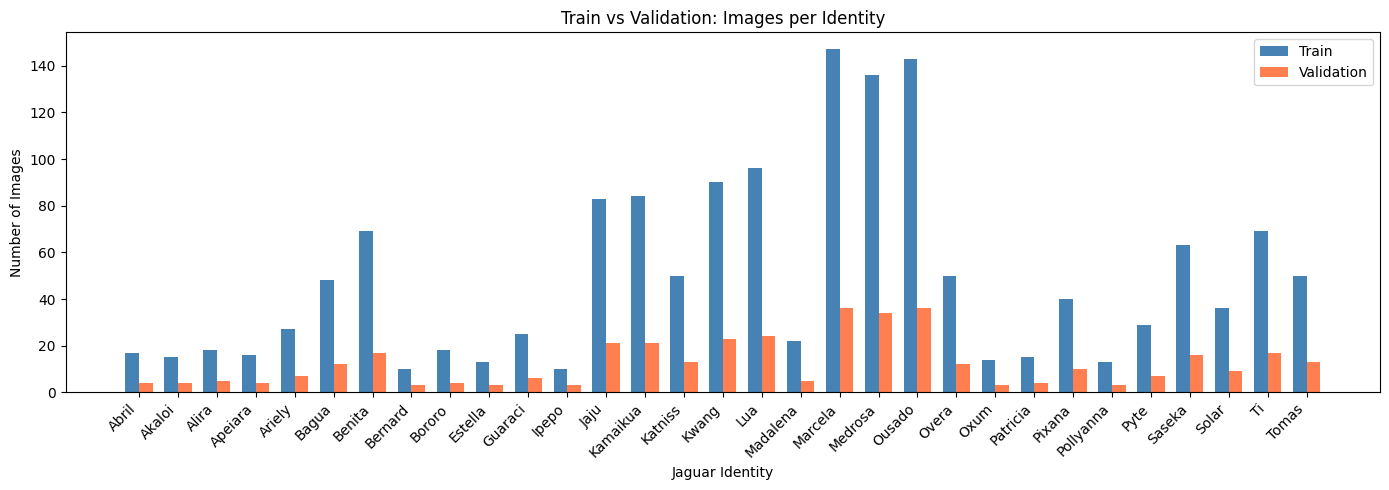


Logged identity distributions to W&B
  Train samples per identity: 10 - 147 (mean: 48.9)
  Val samples per identity: 3 - 36 (mean: 12.2)


In [6]:
# Create stratified train/validation split
# This ensures all identities appear in both sets

# Encode labels to integers
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

# Stratified split: each identity's images are split proportionally
train_data, val_data = train_test_split(
    train_df,
    test_size=config["val_split"],
    random_state=config["seed"],
    stratify=train_df['ground_truth']  # Ensures proportional representation
)

print(f"Dataset split:")
print(f"  Training:   {len(train_data)} images ({100*(1-config['val_split']):.0f}%)")
print(f"  Validation: {len(val_data)} images ({100*config['val_split']:.0f}%)")

# Verify all identities are in both sets
train_identities = set(train_data['ground_truth'].unique())
val_identities = set(val_data['ground_truth'].unique())

print(f"\nIdentity coverage:")
print(f"  Identities in training:   {len(train_identities)}")
print(f"  Identities in validation: {len(val_identities)}")
print(f"  Overlap: {len(train_identities & val_identities)}")

if train_identities == val_identities:
    print("  All identities present in both sets")

# Log identity distributions to W&B
train_counts = train_data['ground_truth'].value_counts().sort_index()
val_counts = val_data['ground_truth'].value_counts().sort_index()

# Create a comparison table for W&B
distribution_df = pd.DataFrame({
    'identity': train_counts.index,
    'train_count': train_counts.values,
    'val_count': val_counts.values,
    'total_count': train_counts.values + val_counts.values,
    'train_ratio': train_counts.values / (train_counts.values + val_counts.values)
})

# Log table and summary stats to W&B
wandb.log({
    "identity_distribution_table": wandb.Table(dataframe=distribution_df),
    "num_identities": num_classes,
    "train_samples": len(train_data),
    "val_samples": len(val_data),
    "train_samples_per_identity": wandb.Histogram(train_counts.values),
    "val_samples_per_identity": wandb.Histogram(val_counts.values),
})

# Visualize train vs val distribution
fig, ax = plt.subplots(figsize=(14, 5))
width = 0.35
x = np.arange(len(train_counts))
ax.bar(x - width/2, train_counts.values, width, label='Train', color='steelblue')
ax.bar(x + width/2, val_counts.values, width, label='Validation', color='coral')
ax.set_xlabel('Jaguar Identity')
ax.set_ylabel('Number of Images')
ax.set_title('Train vs Validation: Images per Identity')
ax.set_xticks(x)
ax.set_xticklabels(train_counts.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
wandb.log({"train_val_distribution": wandb.Image(fig)})
plt.show()

print(f"\nLogged identity distributions to W&B")
print(f"  Train samples per identity: {train_counts.min()} - {train_counts.max()} (mean: {train_counts.mean():.1f})")
print(f"  Val samples per identity: {val_counts.min()} - {val_counts.max()} (mean: {val_counts.mean():.1f})")

## Training Utils

In [7]:
device = get_device()
print(f"Using device: {device}")

Using CUDA GPU
Using device: cuda


In [8]:
filenames = train_df.index.astype(str)
train_mask = filenames.isin(train_data.index.astype(str))

filenames = filenames.to_numpy()
labels = train_df["label_encoded"].to_numpy()
image_paths = [DATA_PATH / "train" / fn for fn in filenames]

In [9]:
@torch.no_grad()
def extract_embeddings(model, data_loader, desc="Extracting embeddings"):
    """Extract embeddings for a batch of images."""
    model.eval()
    embeddings = []

    for batch in tqdm(data_loader, desc=desc):
        batch = batch.to(device)
        with torch.no_grad():
            emb = model(batch)
        embeddings.append(emb.cpu().numpy())

    return np.concatenate(embeddings, axis=0)

print("Embedding extraction function defined")

Embedding extraction function defined


In [10]:
# Extract baseline embeddings for training data

def _load_cached_embeddings(cache_path, expected_filenames):
    z = np.load(cache_path, allow_pickle=True)
    cached_embeddings = z["embeddings"]
    cached_filenames = z["filenames"].tolist() if isinstance(z["filenames"], np.ndarray) else list(z["filenames"])

    if len(cached_filenames) != len(expected_filenames):
        return None

    if set(cached_filenames) != set(expected_filenames):
        return None

    idx = {fn: i for i, fn in enumerate(cached_filenames)}
    return np.stack([cached_embeddings[idx[fn]] for fn in expected_filenames], axis=0)

def get_embeddings(model, cache_path, data_loader):
    embeddings = None
    if cache_path.exists():
        embeddings = _load_cached_embeddings(cache_path, filenames)
        if embeddings is not None:
            print(f"Loaded cached embeddings from {cache_path}")
            print(f"Embeddings shape: {embeddings.shape}")
            
    if embeddings is None:
        print(f"Extracting embeddings for {len(data_loader)} images...")
        embeddings = extract_embeddings(
            model,
            data_loader
        )
        np.savez_compressed(
            cache_path,
            embeddings=embeddings,
            filenames=np.array(filenames, dtype=object),
        )
        print(f"Saved embeddings cache to {cache_path}")
        print(f"Embeddings shape: {embeddings.shape}")
        
    return embeddings


In [11]:
train_labels = train_data.loc[filenames[train_mask], "label_encoded"].values
val_labels = val_data.loc[filenames[~train_mask], "label_encoded"].values

In [12]:
class EmbeddingProjection(nn.Module):
    """
    Projects embeddings to a lower-dimensional space.
    Architecture: input_dim -> hidden_dim -> output_dim
    """
    
    def __init__(self, input_dim=1536, hidden_dim=512, output_dim=256, dropout=0.3):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_dim, output_dim),
            nn.BatchNorm1d(output_dim),
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
                
    def reset(self):
        self._init_weights()
    
    def forward(self, x):
        return self.network(x)

print("EmbeddingProjection defined")

EmbeddingProjection defined


In [ ]:
class ImageDataset(Dataset):
    """PyTorch Dataset for images."""
    
    def __init__(self, filepaths, preprocess):
        self.filepaths = filepaths
        self.preprocess = preprocess
        
    def blur_background(self, img):
        img = np.array(img.convert("RGBA"))

        if img.shape[2] != 4:
            raise ValueError("Input image must have 4 channels (RGBA)")

        rgb = img[:, :, :3]
        alpha = img[:, :, 3]

        blurred = cv2.GaussianBlur(rgb, (0, 0), sigmaX=10, sigmaY=10)

        mask = alpha == 0
        rgb = rgb.copy()
        rgb[mask] = blurred[mask]

        return Image.fromarray(rgb)

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        image = Image.open(self.filepaths[idx]).convert("RGBA")
        image = self.blur_background(image)
        return self.preprocess(image)

In [14]:
class EmbeddingDataset(Dataset):
    """PyTorch Dataset for pre-computed embeddings."""
    
    def __init__(self, embeddings, labels):
        self.embeddings = torch.FloatTensor(embeddings)
        self.labels = torch.LongTensor(labels)
        
        assert len(self.embeddings) == len(self.labels), "Embeddings and labels must have the same length"
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.embeddings[idx], self.labels[idx]

In [15]:
def compute_validation_map(model, val_loader):
    """
    Compute identity-balanced mean Average Precision on validation set.
    
    This simulates the competition metric:
    1. For each query, rank all other images by cosine similarity
    2. Compute Average Precision based on where true matches appear
    3. Average APs within each identity, then average across identities
    """
    model.eval()
    
    val_embeddings = []
    val_labels = []
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            embeddings = model(images)
            embeddings = F.normalize(embeddings, p=2, dim=1)
            val_embeddings.append(embeddings.cpu().numpy())
            val_labels.append(labels.cpu().numpy())

    val_embeddings = np.concatenate(val_embeddings)
    val_labels = np.concatenate(val_labels)

    # Compute cosine similarity matrix
    sim_matrix = cosine_similarity(val_embeddings)
    np.fill_diagonal(sim_matrix, -1)  # Exclude self-similarity

    # Compute AP for each query
    query_aps = {}
    
    for query_idx in range(len(val_labels)):
        query_label = val_labels[query_idx]
        
        # Get similarities to all gallery images (excluding self)
        similarities = sim_matrix[query_idx]
        
        # True labels for gallery
        gallery_labels = val_labels.copy()
        is_match = (gallery_labels == query_label).astype(int)
        is_match[query_idx] = 0  # Exclude self
        
        # Sort by similarity descending
        sorted_indices = np.argsort(-similarities)
        sorted_matches = is_match[sorted_indices]
        
        # Compute Average Precision
        n_positives = sorted_matches.sum()
        if n_positives == 0:
            continue
        
        cumsum = np.cumsum(sorted_matches)
        precision_at_k = cumsum / np.arange(1, len(sorted_matches) + 1)
        ap = np.sum(precision_at_k * sorted_matches) / n_positives
        
        query_aps[query_idx] = (query_label, ap)
    
    # Group by identity and compute identity-balanced mAP
    identity_aps = {}
    for query_idx, (label, ap) in query_aps.items():
        if label not in identity_aps:
            identity_aps[label] = []
        identity_aps[label].append(ap)
    
    # Average within identity, then across identities
    identity_mean_aps = [np.mean(aps) for aps in identity_aps.values()]
    balanced_map = np.mean(identity_mean_aps)
    
    return balanced_map


print("Validation mAP function defined")

Validation mAP function defined


In [16]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    total = 0
    
    pbar = tqdm(loader, desc='Training', leave=False)
    for embeddings, labels in pbar:
        embeddings, labels = embeddings.to(device), labels.to(device)
        
        # Forward pass
        finetuned_embeddings = model(embeddings)
        loss = criterion(finetuned_embeddings, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Metrics
        total_loss += loss.item()
        total += labels.size(0)
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(loader)
    return avg_loss


def validate_epoch(model, loader, criterion, device):
    """Validate for one epoch."""
    model.eval()
    total_loss = 0
    total = 0
    
    with torch.no_grad():
        pbar = tqdm(loader, desc='Validation', leave=False)
        for embeddings, labels in pbar:
            embeddings, labels = embeddings.to(device), labels.to(device)

            finetuned_embeddings = model(embeddings)
            loss = criterion(finetuned_embeddings, labels)

            total_loss += loss.item()
            total += labels.size(0)
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = total_loss / len(loader)
    return avg_loss


print("Training and validation functions defined")

Training and validation functions defined


In [17]:
def train(model, train_loader, val_loader, criterion, optimizer, scheduler, device, name):
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'val_map': [], 'lr': []
    }

    best_val_map = 0.0
    patience_counter = 0
    best_epoch = 0

    print(f"Starting training for {config['num_epochs']} epochs...")
    print("=" * 70)

    for epoch in range(config['num_epochs']):
        print(f"\nEpoch {epoch+1}/{config['num_epochs']}")
        
        # Train
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validate
        val_loss = validate_epoch(model, val_loader, criterion, device)
        
        # Compute validation mAP
        val_map = compute_validation_map(
            model, 
            val_loader,
        )
        
        # Update scheduler
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        
        # Store history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_map'].append(val_map)
        history['lr'].append(current_lr)
        
        # Log to W&B
        wandb.log({
            'model': name,
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_map': val_map,
            'learning_rate': current_lr,
        })
        
        # Print summary
        print(f"  Train Loss: {train_loss:.4f}")
        print(f"  Val Loss:   {val_loss:.4f}")
        print(f"  Val mAP:    {val_map:.4f} | LR: {current_lr:.2e}")
        
        # Checkpoint best model
        if val_map > best_val_map:
            best_val_map = val_map
            best_epoch = epoch + 1
            patience_counter = 0

            checkpoint_path = CHECKPOINT_PATH / f"model_best_{name}.pth"
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
                'val_map': val_map,
                'config': config,
                'label_encoder_classes': label_encoder.classes_.tolist(),
                'num_classes': num_classes,
                'name': name
            }, checkpoint_path)
            
            print(f"  [New best model saved]")
        else:
            patience_counter += 1
            print(f"  No improvement. Patience: {patience_counter}/{config['patience']}")
        
        # Early stopping
        if patience_counter >= config['patience']:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            break

    print("\n" + "=" * 70)
    print(f"Training complete!")
    print(f"Best epoch: {best_epoch}, Val mAP: {best_val_map:.4f}")

    return history, best_val_map, best_epoch

print("Train function defined")

Train function defined


In [18]:
def plot_history(history, best_epoch):
    # Plot training curves
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))

    epochs_range = range(1, len(history['train_loss']) + 1)

    # Loss
    axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Train')
    axes[0].plot(epochs_range, history['val_loss'], 'r-', label='Validation')
    axes[0].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7, label=f'Best ({best_epoch})')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # mAP
    axes[1].plot(epochs_range, history['val_map'], 'purple', linewidth=2)
    axes[1].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('mAP')
    axes[1].set_title('Validation mAP (Identity-Balanced)')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    
    return fig


In [19]:
# Load Dino model
print("Loading Dino model...")
dino = timm.create_model(
    config["dinov3_model"],
    pretrained=True
)
dino.eval()
dino.to(device)
dino.compile()

dino_config = resolve_data_config({}, model=dino)
dino_preprocess = create_transform(**dino_config, is_training=False)

dino_num_params = sum(p.numel() for p in dino.parameters())

print(f"Model loaded successfully")
print(f"  Parameters: {dino_num_params:,}")
print(f"  Preprocessing: {dino_config}")

# Get the embedding dimension from the model
with torch.no_grad():
    input_size = dino_config["input_size"]
    dummy_input = torch.randn(1, input_size[0], input_size[1], input_size[2]).to(device)
    dummy_output = dino(dummy_input)
    dino_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {dino_dim}")

Loading Dino model...


Model loaded successfully
  Parameters: 85,641,216
  Preprocessing: {'input_size': [3, 256, 256], 'interpolation': 'bicubic', 'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225], 'crop_pct': 1.0, 'crop_mode': 'center'}
  Embedding dimension: 768


In [20]:
image_dataset = ImageDataset(image_paths, dino_preprocess)
image_loader = DataLoader(
    image_dataset,
    batch_size=config["batch_size"],
    num_workers=2,
    shuffle=False
)

print(f"Image DataLoader created with {len(image_loader)} batches")

Image DataLoader created with 60 batches


In [21]:
baseline_cache_path = EMBEDDINGS_PATH / "dino_baseline_embeddings.npz"

baseline_embeddings = get_embeddings(
    dino,
    baseline_cache_path,
    image_loader
)

Extracting embeddings for 60 images...


Extracting embeddings: 100%|██████████| 60/60 [06:18<00:00,  6.30s/it]


Saved embeddings cache to /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss_combined/embeddings/dino_baseline_embeddings.npz
Embeddings shape: (1895, 768)


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


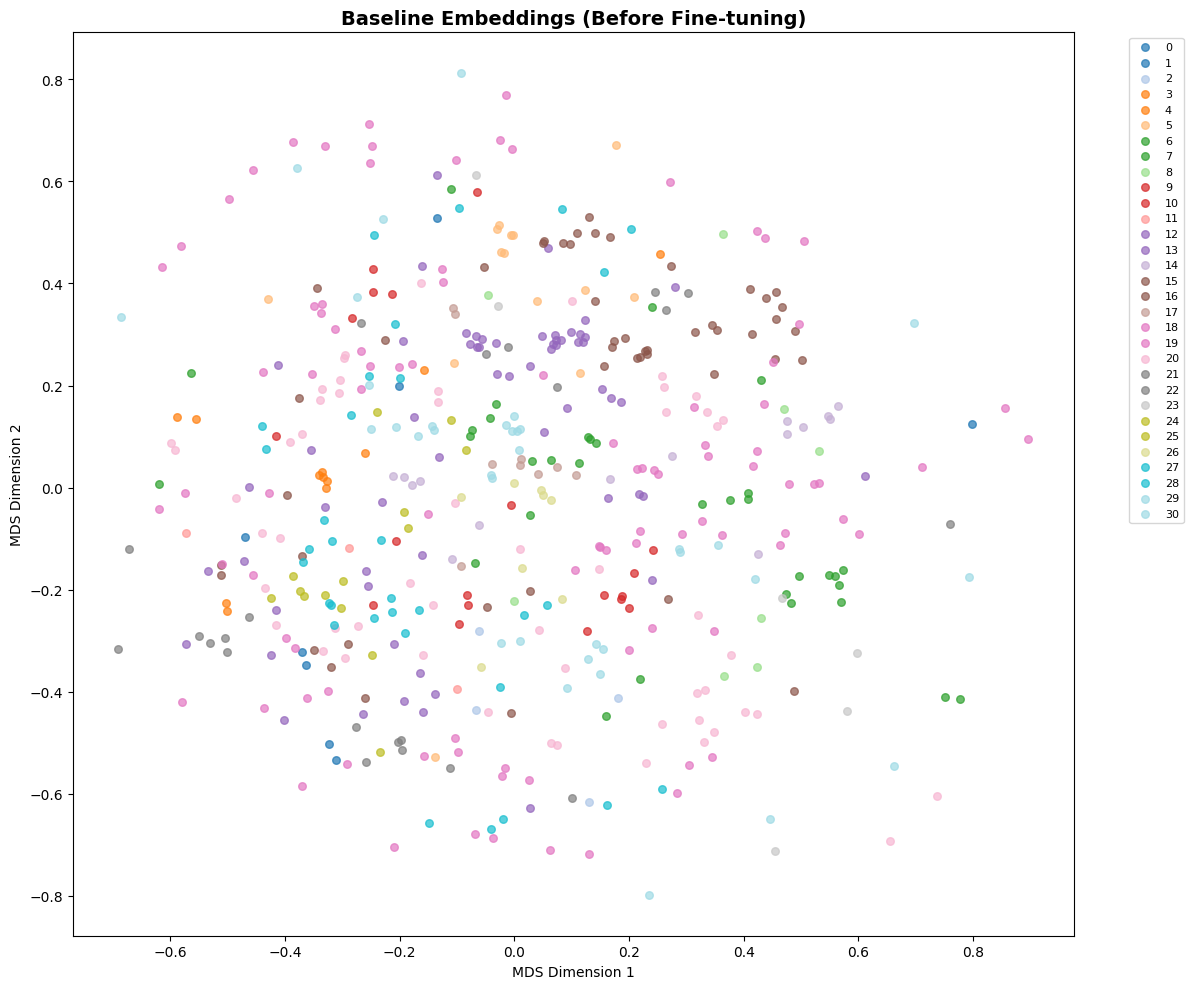

In [22]:
# Visualize DINO embeddings
fig = visualize_embeddings_mds(
    baseline_embeddings,
    labels,
    "Baseline Embeddings (Before Fine-tuning)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "baseline_embeddings_mds.png")
plt.show()

# Log to W&B
wandb.log({"baseline_embeddings_mds": wandb.Image(fig)})

In [23]:
baseline_emb_train_dataset = EmbeddingDataset(
    baseline_embeddings[train_mask],
    train_labels
)

baseline_emb_val_dataset = EmbeddingDataset(
    baseline_embeddings[~train_mask],
    val_labels
)

baseline_emb_train_loader = create_deterministic_training_dataloader(
    baseline_emb_train_dataset,
    batch_size=config["batch_size"],
)
baseline_emb_val_loader = DataLoader(
    baseline_emb_val_dataset,
    batch_size=config["batch_size"],
    num_workers=2,
    shuffle=False
)

In [24]:
# Create model
model = EmbeddingProjection(
    input_dim=dino_dim,
    hidden_dim=config["hidden_dim"],
    output_dim=config["embedding_dim"],
    dropout=config["dropout"],
).to(device)

model_num_params = sum(p.numel() for p in model.parameters())

print(f"Embedding Projection Model defined:")
print(f"  Total parameters: {model_num_params:,}")

Embedding Projection Model defined:
  Total parameters: 526,592


In [25]:
# Export initial model weights for reinitialization
initial_weights_path = CHECKPOINT_PATH / "model_initial_weights.pth"
torch.save(model.state_dict(), initial_weights_path)
print(f"Initial model weights saved to {initial_weights_path}")

Initial model weights saved to /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss_combined/model_initial_weights.pth


In [26]:
table = [
    ["Loss Function", "Best val_mAP", "Best epoch"]
]

## Proxy Anchor Loss

In [27]:
class ProxyAnchorLoss(nn.Module):
    def __init__(self, num_classes, embedding_dim, margin=0.1, alpha=32):
        super().__init__()
        self.proxies = nn.Parameter(torch.randn(num_classes, embedding_dim))
        nn.init.kaiming_normal_(self.proxies, mode='fan_out')
        self.margin = margin
        self.alpha = alpha

    def forward(self, features, labels):
        features = F.normalize(features)
        proxies = F.normalize(self.proxies)

        sim = F.linear(features, proxies)  # cosine similarity

        pos_mask = F.one_hot(labels, num_classes=sim.size(1)).bool()
        neg_mask = ~pos_mask

        pos_exp = torch.exp(-self.alpha * (sim - self.margin)) * pos_mask
        neg_exp = torch.exp(self.alpha * (sim + self.margin)) * neg_mask

        pos_term = torch.log(1 + pos_exp.sum(dim=0)).sum()
        neg_term = torch.log(1 + neg_exp.sum(dim=0)).sum()

        loss = (pos_term + neg_term) / features.size(0)
        return loss
    
print(f"ProxyAnchor Model:")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Num classes: {num_classes}")
print(f"  ProxyAnchor margin: {config['proxyanchor_margin']}")
print(f"  ProxyAnchor alpha: {config['proxyanchor_alpha']}")

ProxyAnchor Model:
  Embedding dim: 256
  Num classes: 31
  ProxyAnchor margin: 0.1
  ProxyAnchor alpha: 32.0


In [28]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

criterion = ProxyAnchorLoss(
    num_classes=num_classes, 
    embedding_dim=config["embedding_dim"], 
    margin=config["proxyanchor_margin"], 
    alpha=config["proxyanchor_alpha"]
).to(device)

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,
)

print("Training components initialized:")
print(f"  Loss: ProxyAnchorLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Training components initialized:
  Loss: ProxyAnchorLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [29]:
# Training loop
set_seeds(config['seed'])
history, best_map, best_epoch = train(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="proxyanchor"
)

wandb.log({
    "final_val_mAP_proxyanchor": best_map,
    "best_epoch_proxyanchor": best_epoch,
    "total_epochs_proxyanchor": len(history['train_loss']),
})

table.append([
    "ProxyAnchor",
    best_map,
    best_epoch
])

All random seeds set to 51 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


Training:   0%|          | 0/48 [00:00<?, ?it/s]

  Train Loss: 9.7816
  Val Loss:   7.9424
  Val mAP:    0.3412 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 8.9162
  Val Loss:   7.6274
  Val mAP:    0.3482 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 8.5283
  Val Loss:   7.4300
  Val mAP:    0.3506 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


...

  Train Loss: 0.1918
  Val Loss:   0.7368
  Val mAP:    0.8683 | LR: 2.50e-05
  No improvement. Patience: 6/10

Epoch 141/200


  Train Loss: 0.1956
  Val Loss:   0.7244
  Val mAP:    0.8660 | LR: 2.50e-05
  No improvement. Patience: 7/10

Epoch 142/200


  Train Loss: 0.1936
  Val Loss:   0.7270
  Val mAP:    0.8688 | LR: 2.50e-05
  No improvement. Patience: 8/10

Epoch 143/200


  Train Loss: 0.1947
  Val Loss:   0.7357
  Val mAP:    0.8687 | LR: 2.50e-05
  No improvement. Patience: 9/10

Epoch 144/200


  Train Loss: 0.1814
  Val Loss:   0.7336
  Val mAP:    0.8681 | LR: 2.50e-05
  No improvement. Patience: 10/10

Early stopping triggered after 144 epochs

Training complete!
Best epoch: 134, Val mAP: 0.8696


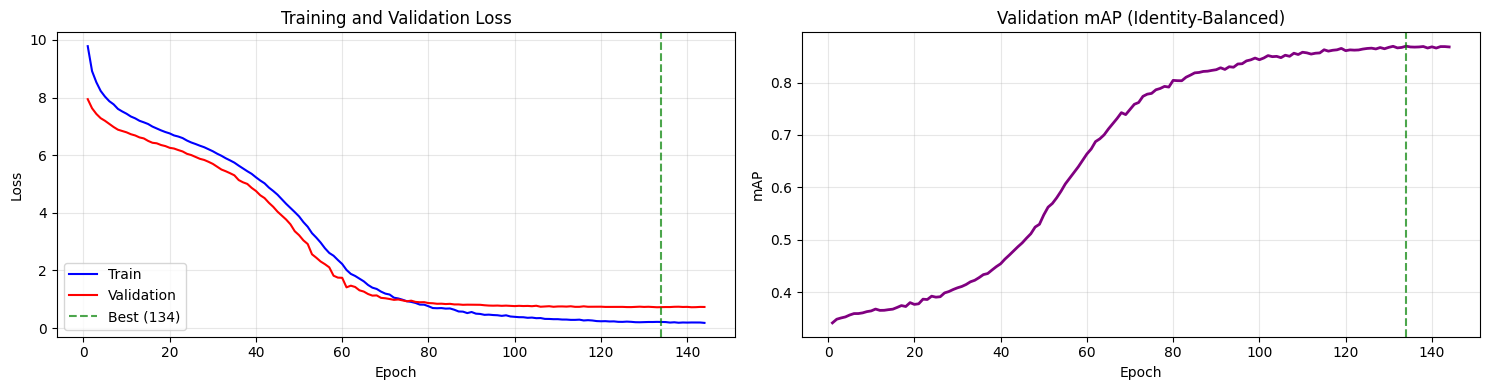

In [30]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_proxyanchor.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_proxyanchor": wandb.Image(fig)})

In [31]:
# Load best model
checkpoint = torch.load(CHECKPOINT_PATH / "model_best_proxyanchor.pth", map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {CHECKPOINT_PATH}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss_combined
  Val Loss: 0.7292
  Val mAP: 0.8696


In [32]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


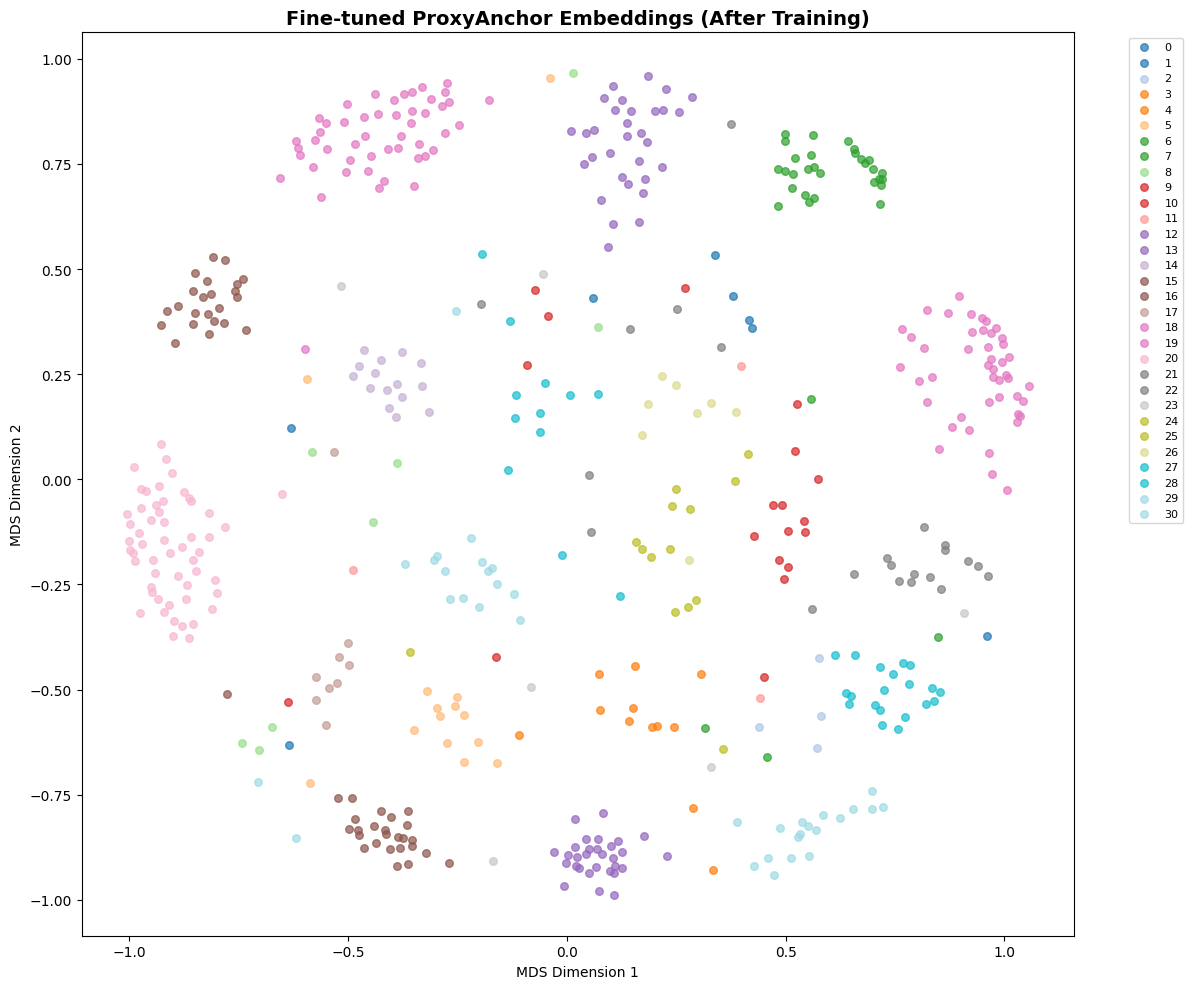

In [33]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned ProxyAnchor Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "proxyanchor_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_proxyanchor": wandb.Image(fig_finetuned)})

In [34]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Proxy Anchor Loss + Center Loss

In [35]:
class CenterLoss(nn.Module):
    def __init__(self, embedding_dim, num_classes):
        super().__init__()
        self.centers = nn.Parameter(torch.randn(num_classes, embedding_dim))

    def forward(self, features, labels):
        centers_batch = self.centers[labels]
        loss = ((features - centers_batch) ** 2).sum(dim=1).mean()
        return loss

print(f"Center Loss:")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Num classes: {num_classes}")


Center Loss:
  Embedding dim: 256
  Num classes: 31


In [36]:
class CombinedLoss(nn.Module):
    def __init__(self, proxy_anchor_loss, center_loss, lambda_center=0.1):
        super().__init__()
        self.proxy_anchor_loss = proxy_anchor_loss
        self.center_loss = center_loss
        self.lambda_center = lambda_center

    def forward(self, features, labels):
        loss_proxy_anchor = self.proxy_anchor_loss(features, labels)
        loss_center = self.center_loss(features, labels)
        total_loss = loss_proxy_anchor + self.lambda_center * loss_center
        return total_loss
    
print(f"Combined Loss:")
print(f"  Components: ProxyAnchorLoss + CenterLoss")
print(f"  Lambda for Center Loss: {config['combined_lambda']}")

Combined Loss:
  Components: ProxyAnchorLoss + CenterLoss
  Lambda for Center Loss: 0.5


In [41]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

criterion = CombinedLoss(
    proxy_anchor_loss=ProxyAnchorLoss(
        num_classes=num_classes,
        embedding_dim=config["embedding_dim"],
        margin=config["proxyanchor_margin"],
        alpha=config["proxyanchor_alpha"]
    ),
    center_loss=CenterLoss(
        embedding_dim=config["embedding_dim"],
        num_classes=num_classes
    ),
    lambda_center=config["combined_lambda"]
).to(device)

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,
)

print("Training components initialized:")
print(f"  Loss: ProxyAnchorLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Training components initialized:
  Loss: ProxyAnchorLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [42]:
# Training loop
set_seeds(config['seed'])
history, best_map, best_epoch = train(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="combined_proxyanchor_center"
)

wandb.log({
    "final_val_mAP_combined": best_map,
    "best_epoch_combined": best_epoch,
    "total_epochs_combined": len(history['train_loss']),
})

table.append([
    "Combined (ProxyAnchor + Center)",
    best_map,
    best_epoch
])

All random seeds set to 51 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


Training:   0%|          | 0/48 [00:00<?, ?it/s, loss=259.2316]

  Train Loss: 252.8357
  Val Loss:   188.6249
  Val mAP:    0.3508 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 226.7838
  Val Loss:   174.0423
  Val mAP:    0.3740 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 206.9638
  Val Loss:   157.2410
  Val mAP:    0.3970 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


...

  Train Loss: 10.9585
  Val Loss:   12.4794
  Val mAP:    0.8723 | LR: 1.00e-04
  No improvement. Patience: 6/10

Epoch 195/200


  Train Loss: 11.0864
  Val Loss:   12.4240
  Val mAP:    0.8739 | LR: 1.00e-04
  No improvement. Patience: 7/10

Epoch 196/200


  Train Loss: 10.7555
  Val Loss:   12.3158
  Val mAP:    0.8713 | LR: 1.00e-04
  No improvement. Patience: 8/10

Epoch 197/200


  Train Loss: 10.6287
  Val Loss:   12.4265
  Val mAP:    0.8724 | LR: 1.00e-04
  No improvement. Patience: 9/10

Epoch 198/200


  Train Loss: 10.2653
  Val Loss:   12.2204
  Val mAP:    0.8728 | LR: 1.00e-04
  No improvement. Patience: 10/10

Early stopping triggered after 198 epochs

Training complete!
Best epoch: 188, Val mAP: 0.8750


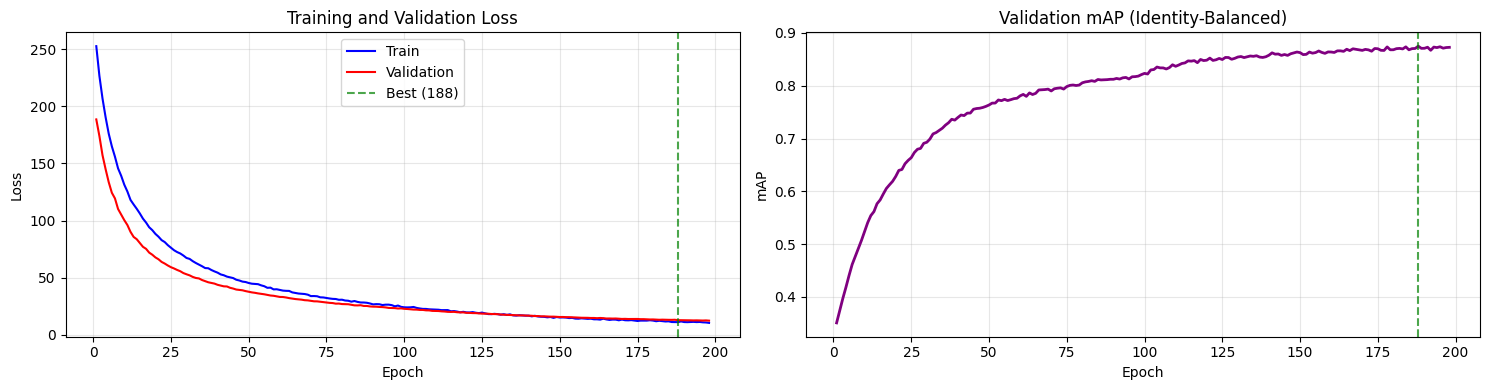

In [43]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_combined.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_combined": wandb.Image(fig)})

In [44]:
# Load best model
checkpoint = torch.load(CHECKPOINT_PATH / "model_best_combined_proxyanchor_center.pth", map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {CHECKPOINT_PATH}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss_combined
  Val Loss: 12.6584
  Val mAP: 0.8750


In [45]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


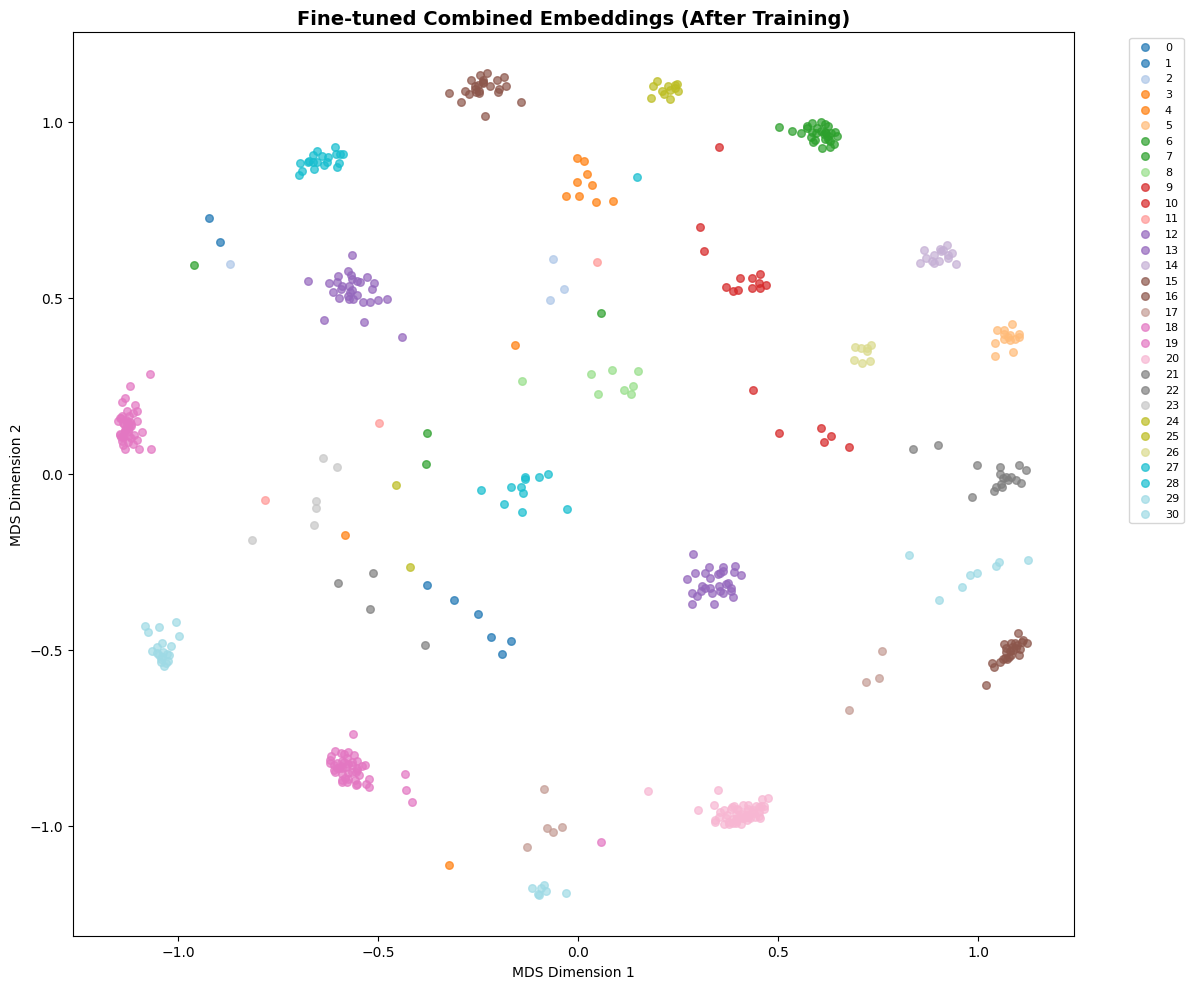

In [46]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned Combined Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "combined_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_combined": wandb.Image(fig_finetuned)})

In [47]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Summary

In [48]:
rows = list(zip(*table)) # transpose for tabulate
print(tabulate(rows[1:], headers=rows[0], tablefmt="grid"))

+-----------------+---------------+-----------------------------------+-----------------------------------+
| Loss Function   |   ProxyAnchor |   Combined (ProxyAnchor + Center) |   Combined (ProxyAnchor + Center) |
+=================+===============+===================================+===================================+
| Best val_mAP    |      0.869559 |                          0.855381 |                          0.875018 |
+-----------------+---------------+-----------------------------------+-----------------------------------+
| Best epoch      |    134        |                          1        |                        188        |
+-----------------+---------------+-----------------------------------+-----------------------------------+


## Submission

In [49]:
checkpoint = torch.load(CHECKPOINT_PATH / "model_best_combined_proxyanchor_center.pth", map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

EmbeddingProjection(
  (network): Sequential(
    (0): Linear(in_features=768, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)

In [50]:
# Load test.csv to get the pairs we need to score
test_pairs_df = pd.read_csv(DATA_PATH / "test.csv")

print(f"Test pairs to score: {len(test_pairs_df)}")
print(f"Columns: {list(test_pairs_df.columns)}")
print(f"\nSample rows:")
print(test_pairs_df.head())

Test pairs to score: 137270
Columns: ['row_id', 'query_image', 'gallery_image']

Sample rows:
   row_id    query_image  gallery_image
0       0  test_0001.png  test_0002.png
1       1  test_0001.png  test_0003.png
2       2  test_0001.png  test_0004.png
3       3  test_0001.png  test_0005.png
4       4  test_0001.png  test_0006.png


In [51]:
# Get unique test images
test_images = set(test_pairs_df['query_image'].unique()) | set(test_pairs_df['gallery_image'].unique())
test_images = sorted(list(test_images))

print(f"Unique test images: {len(test_images)}")

# Build paths
test_image_paths = [DATA_PATH / "test" / filename for filename in test_images]

test_loader = DataLoader(
    ImageDataset(test_image_paths, dino_preprocess),
    batch_size=config["batch_size"],
    num_workers=2,
    shuffle=False
)

# Extract embeddings for test images
print(f"\nExtracting embeddings for test images...")
test_embeddings = extract_embeddings(
    dino,
    test_loader,
    desc="Test embeddings"
)

print(f"Test embeddings shape: {test_embeddings.shape}")

Unique test images: 371

Extracting embeddings for test images...


Test embeddings: 100%|██████████| 12/12 [01:10<00:00,  5.92s/it]

Test embeddings shape: (371, 768)


In [52]:
# Project through fine-tuned model
model.eval()
with torch.no_grad():
    test_tensor = torch.FloatTensor(test_embeddings).to(device)
    test_finetuned_embeddings = model(test_tensor).cpu().numpy()
    test_finetuned_embeddings = test_finetuned_embeddings / np.linalg.norm(test_finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned test embeddings shape: {test_finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(test_finetuned_embeddings, axis=1).mean():.4f}")

# Create mapping from filename to embedding
img_to_embedding = {
    filename: embedding 
    for filename, embedding in zip(test_images, test_finetuned_embeddings)
}

Fine-tuned test embeddings shape: (371, 256)
Mean L2 norm: 1.0000


In [53]:
# Compute similarity for each pair
print("Computing pairwise similarities...")
similarities = []

for _, row in tqdm(test_pairs_df.iterrows(), total=len(test_pairs_df), desc="Computing similarities"):
    query_emb = img_to_embedding[row['query_image']]
    gallery_emb = img_to_embedding[row['gallery_image']]
    
    # Cosine similarity (embeddings are already normalized)
    sim = np.dot(query_emb, gallery_emb)
    similarities.append(sim)

# Clip to [0, 1] range
similarities = np.array(similarities)
similarities = np.clip(similarities, 0.0, 1.0)

print(f"\nSimilarity statistics:")
print(f"  Min: {similarities.min():.4f}")
print(f"  Max: {similarities.max():.4f}")
print(f"  Mean: {similarities.mean():.4f}")
print(f"  Std: {similarities.std():.4f}")

Computing pairwise similarities...


Computing similarities: 100%|██████████| 137270/137270 [00:04<00:00, 29184.13it/s]


Similarity statistics:
  Min: 0.0000
  Max: 0.9987
  Mean: 0.1389
  Std: 0.1952


In [54]:
# Create submission DataFrame
submission_df = pd.DataFrame({
    'row_id': test_pairs_df['row_id'],
    'similarity': similarities
})

print("Submission DataFrame:")
print(submission_df.head(10))

# Verify format matches sample submission
sample_submission = pd.read_csv(DATA_PATH / "sample_submission.csv")
print(f"\nFormat check:")
print(f"  Expected columns: {list(sample_submission.columns)}")
print(f"  Our columns: {list(submission_df.columns)}")
print(f"  Expected rows: {len(sample_submission)}")
print(f"  Our rows: {len(submission_df)}")

Submission DataFrame:
   row_id  similarity
0       0    0.829533
1       1    0.227029
2       2    0.825752
3       3    0.000000
4       4    0.000000
5       5    0.493684
6       6    0.347619
7       7    0.130230
8       8    0.000000
9       9    0.213450

Format check:
  Expected columns: ['row_id', 'similarity']
  Our columns: ['row_id', 'similarity']
  Expected rows: 137270
  Our rows: 137270


In [55]:
# Save submission
submission_path = OUTPUT_PATH / "submission.csv"
submission_df.to_csv(submission_path, index=False)

print(f"Submission saved to: {submission_path}")
print(f"File size: {submission_path.stat().st_size / 1024:.1f} KB")

Submission saved to: /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/output/loss_combined/submission.csv
File size: 2073.8 KB
